# 006 - QUBO Analysis  

## Admin



### Python Libraries 

In [10]:
import pandas as pd 
import Quantum_Optimization_Functions as qof 

import matplotlib.pyplot as plt 
import seaborn as sns 

import numpy as np
from scipy.optimize import minimize, differential_evolution
from itertools import product

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

### Import data 

In [3]:
target_tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'JPM', 'XOM', 'JNJ', 'V']
summary_df, daily_returns = qof.get_assets(companies_list=target_tickers)


In [12]:
summary_df.columns

Index(['Ticker', 'Last Close', 'CAGR (%)', 'Volatility (%)'], dtype='object')

### Create a covariance Matrix 

In [5]:
corr = daily_returns.corr()
cov = daily_returns.cov()
assets = summary_df['Ticker'].to_list()

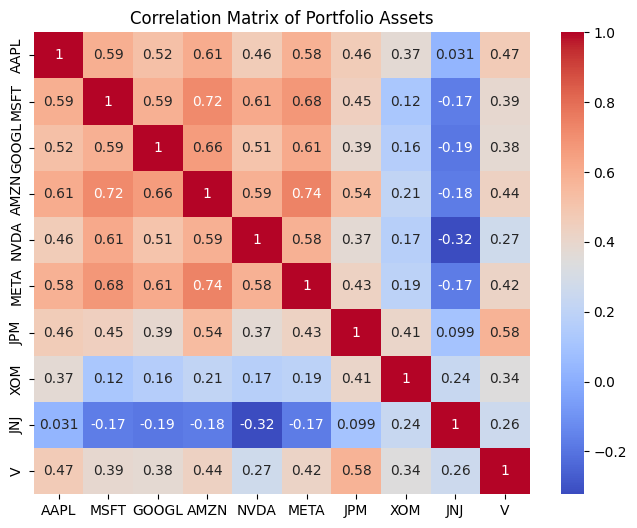

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', xticklabels=assets, yticklabels=assets)
plt.title("Correlation Matrix of Portfolio Assets")
plt.show()

### Set Parameters  

In [14]:
# --- Parameters ---
budget         = 800           # Budget in USD
alpha          = 5             # Budget penalty
return_weight  = 5             # Relative weight of returns in QUBO
risk_weight    = 8             # Relative weight of risk in QUBO (=lambda)
optimizer_iterations = 50      # Number of iterations to optimize gamma/beta
number_of_assets = len(assets)

# Define budget acceptance band (±20%)
band_low  = 0.80 * budget
band_high = 1.20 * budget

### 1.0 -- QUBO Setup (cost, constraints, scaling)


In [15]:
# Quadratic term (risk, budget, asset count)
Q = np.zeros((number_of_assets, number_of_assets))                     # Quadratic term (risk, budget, asset count)

In [ ]:
# Expected annual returns (arithmetic)
mu = daily_returns.mean() * 252
# Align prices with the same ticker ordering
prices = summary_df.set_index("Ticker")["Last Close"]
# Linear term
return_linear_penalty = -return_weight * mu * prices / budget

In [17]:
annual_covariance = daily_returns.cov() * 252

prices = summary_df.set_index("Ticker").loc[
    annual_covariance.index, "Last Close"
]

price_outer = np.outer(prices.values, prices.values)

risk_quadratic_term = (
    risk_weight * annual_covariance.values * price_outer / budget**2
)

Q += risk_quadratic_term